# Projet 4 : Analyser les écarts de performance

### Problématique
L’entreprise cherche à analyser les différences de performance du personnel. Elle souhaite déterminer si ces écarts sont statistiquement significatifs, et identifier les facteurs RH qui influencent la performance.

### Objectif
- Identifier si certains départements performent mieux ou moins bien.
- Explorer les facteurs associés à ces écarts : satisfaction, heures travaillées, salaires, etc.
- Utiliser des tests statistiques pour valider ces différences.


# Importation des librairies et des data

## Librairies

In [86]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing as StandardScaler
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from scipy.stats import ttest_ind
from scipy.stats import f_oneway, mannwhitneyu, kruskal, wilcoxon

## Informations sur la data frame

In [87]:
# Importation de la base de données
if os.path.exists("Extended_Employee_Performance_and_Productivity_Data.csv"):
    perf=pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')  # Local
else:
    url = "https://raw.githubusercontent.com/GeraudTozo/DATA-ANALYST-PROJECT/main/P4/Extended_Employee_Performance_and_Productivity_Data.csv"
    perf = pd.read_csv(url)  # Colab ou cloud

# Visualisation du data set
display(perf)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,Finance,Male,27,Technician,2022-12-07 08:03:05.556036,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28,False
99996,99997,IT,Female,36,Consultant,2018-07-24 08:03:05.556036,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48,True
99997,99998,Operations,Male,53,Analyst,2015-11-24 08:03:05.556036,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60,False
99998,99999,HR,Female,22,Consultant,2015-08-03 08:03:05.556036,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10,False


La base de donnée est composée alors de **100000** employés caractérisés par **20** variables.

In [88]:
# Liste des variables
perf.columns

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')

In [89]:
# Les différents types de variables dans notre base de donnéess
perf.dtypes

Employee_ID                      int64
Department                      object
Gender                          object
Age                              int64
Job_Title                       object
Hire_Date                       object
Years_At_Company                 int64
Education_Level                 object
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object

In [90]:
# Decompte de valeurs manquantes ou incomplètes par variables
perf.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

On remarque que notre base ne contient pas de valeurs manquantes.

In [91]:
# Compter les doublons
perf.duplicated().sum()

0

Ce resultat démontre que notre base ne compte pas de doublons.

# Profil des employés

Avant d'analyser la performance, nous allons explorer le profil global des employés : répartition par âge, ancienneté, salaire, éducation, etc.

Cela permet de mieux comprendre la population de l'entreprise et de repérer d'éventuelles spécificités par département ou groupe.


In [92]:
# Moyennes ou médianes générales
profil_global = perf[["Age", "Years_At_Company", "Monthly_Salary", "Work_Hours_Per_Week",
                    "Projects_Handled", "Overtime_Hours", "Sick_Days", 
                    "Training_Hours", "Employee_Satisfaction_Score"]].median()
profil_global

Age                              41.0
Years_At_Company                  4.0
Monthly_Salary                 6500.0
Work_Hours_Per_Week              45.0
Projects_Handled                 24.0
Overtime_Hours                   15.0
Sick_Days                         7.0
Training_Hours                   49.0
Employee_Satisfaction_Score       3.0
dtype: float64


L’employé type de l’entreprise est un collaborateur expérimenté, avec une charge de travail importante (45h/semaine + 15h d’heures supp.), impliqué sur de nombreux projets avec un salaire de **6500**. Malgré un niveau de formation et d’activité soutenu, le **score de satisfaction est relativement faible (3/10)**, ce qui peut soulever des questions sur la **qualité de vie au travail**, la reconnaissance ou les conditions internes.

## Genre

C:\Users\User\AppData\Local\Temp\ipykernel_6364\2795390074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=perf, x="Gender", order=genre.index, palette="Set1")


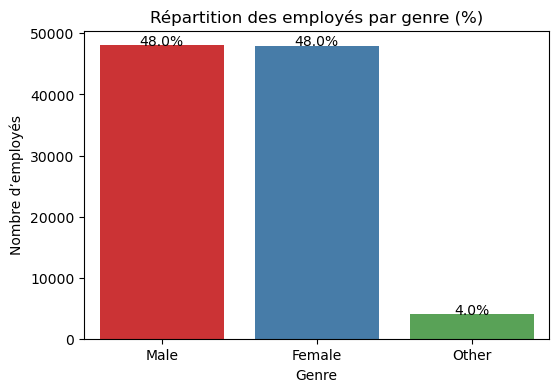

In [93]:
# Calcul des proportions
genre = perf["Gender"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=perf, x="Gender", order=genre.index, palette="Set1")

# Ajouter les pourcentages au-dessus des barres
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / len(perf):.1f}%'
    ax.text(p.get_x() + p.get_width() / 2., height + 1, percentage, ha="center")

plt.title("Répartition des employés par genre (%)")
plt.ylabel("Nombre d’employés")
plt.xlabel("Genre")
plt.show()


In [94]:
genre

Gender
Male      48.031
Female    48.001
Other      3.968
Name: proportion, dtype: float64

Cette parité homme/femme est un atout pour l’analyse : elle **réduit le biais lié au genre** dans les comparaisons inter-départements.

## Niveau d'etude

C:\Users\User\AppData\Local\Temp\ipykernel_6364\3092931622.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=perf, x="Education_Level", order=edu_order, palette="Set1")


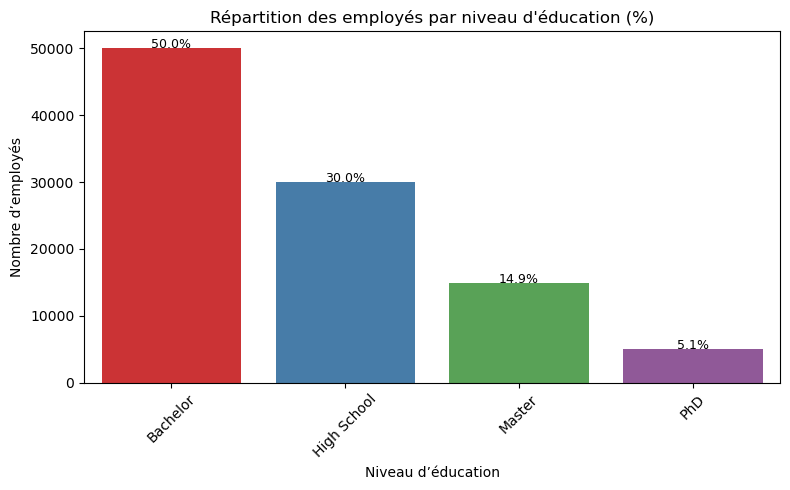

In [95]:
# Calcul des proportions
edu_order = perf["Education_Level"].value_counts(normalize=True).index

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=perf, x="Education_Level", order=edu_order, palette="Set1")

for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / len(perf):.1f}%'
    ax.text(p.get_x() + p.get_width() / 2., height + 1, percentage, ha="center", fontsize=9)

plt.title("Répartition des employés par niveau d'éducation (%)")
plt.xticks(rotation=45)
plt.ylabel("Nombre d’employés")
plt.xlabel("Niveau d’éducation")
plt.tight_layout()
plt.show()


#### Analyse

- **La moitié des employés (50%) ont un diplôme de niveau Bachelor** (équivalent à Bac+3), ce qui en fait le niveau le plus représenté dans l’entreprise.
- **30% ont un diplôme de type lycée (High School)**, ce qui peut suggérer une présence importante de postes techniques ou opérationnels peu qualifiés dans certains départements.
- **Les titulaires de Master (14.9%) et de PhD (5.1%)** représentent ensemble **à peine 1 collaborateur sur 5**, ce qui peut être un point d’attention si l’entreprise vise à développer davantage d’expertise, d’innovation ou de stratégie.

#### Implications possibles :
- Les départements avec une forte concentration de diplômes supérieurs pourraient être corrélés à de meilleures performances ou à des niveaux de satisfaction différents.
- L’entreprise pourrait envisager des **plans de montée en compétence ou de formation continue**, notamment pour les employés issus du secondaire.
- Ce déséquilibre peut également expliquer certaines dynamiques de promotion, d’accès aux responsabilités ou de motivation.

> Ce profil éducatif servira de référence pour analyser les écarts de performance : est-ce que le niveau d’éducation influence les scores ? Les heures travaillées ? La satisfaction ? 

## Poste

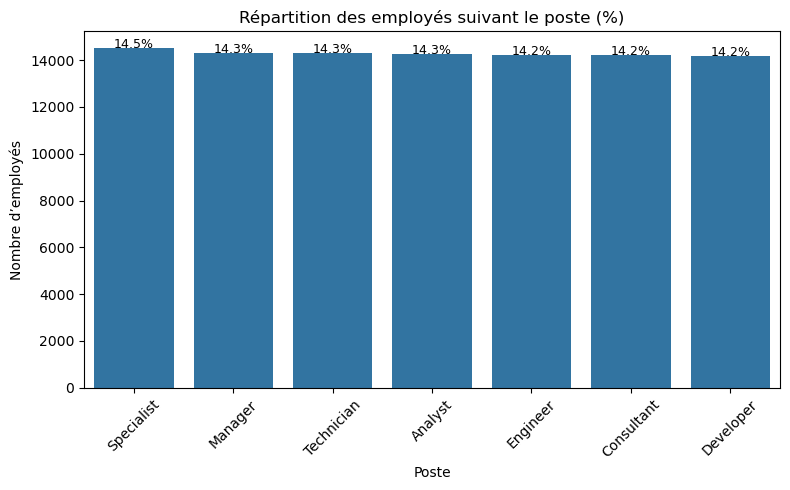

In [96]:
# Calcul des proportions
poste = perf["Job_Title"].value_counts(normalize=True).index

# Representation graphique
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=perf, x="Job_Title", order=poste)

for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / len(perf):.1f}%'
    ax.text(p.get_x() + p.get_width() / 2., height + 1, percentage, ha="center", fontsize=9)

plt.title("Répartition des employés suivant le poste (%)")
plt.xticks(rotation=45)
plt.ylabel("Nombre d’employés")
plt.xlabel("Poste")
plt.tight_layout()
plt.show()

#### Interpretation

- Cette structure suggère que l’entreprise dispose d’un **organigramme bien réparti**, et qu’elle investit autant dans les rôles d’exécution que dans ceux de gestion ou d’expertise.
- Il sera pertinent d’analyser les **écarts de performance ou de satisfaction par poste** :
    - Les **Managers** ont-ils plus d’heures de travail ou de pression ?
    - Les **Analysts ou Engineers** sont-ils mieux notés en performance ?
    - Les **Consultants** ont-ils un taux de satisfaction différent ?
- Cette grille équilibrée permettra d’évaluer si certains postes sont **structurellement favorisés ou défavorisés** dans l’entreprise.

> Cette répartition équitable rend possible une étude fine de l’impact du poste sur la performance, les promotions ou la satisfaction.

## Departement

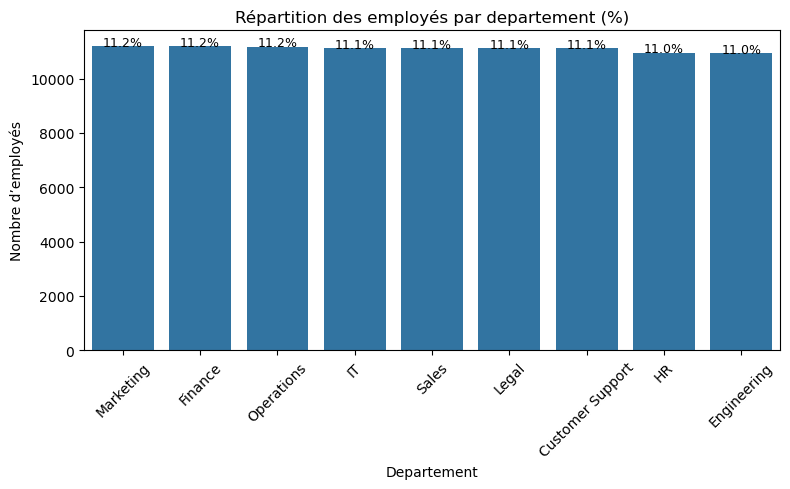

In [97]:
# Calcul des proportions
dep = perf["Department"].value_counts(normalize=True).index

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=perf, x="Department", order=dep)

for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / len(perf):.1f}%'
    ax.text(p.get_x() + p.get_width() / 2., height + 1, percentage, ha="center", fontsize=9)

plt.title("Répartition des employés par departement (%)")
plt.xticks(rotation=45)
plt.ylabel("Nombre d’employés")
plt.xlabel("Departement")
plt.tight_layout()
plt.show()

#### Analyse

- La répartition des effectifs entre les départements est **extrêmement homogène**, avec des proportions comprises entre **11.0 % et 11.2 %** pour chacun.
- Cette **répartition équilibrée** constitue un **atout analytique majeur** : elle garantit que les comparaisons de performance, de satisfaction ou d'autres indicateurs entre départements **ne seront pas biaisées par un déséquilibre d'effectif**.
- Elle suggère également que **l'entreprise a structuré ses ressources humaines de façon uniforme** à travers ses différentes fonctions clés.

#### Implications possibles :

- Les résultats des tests statistiques (ANOVA, Khi², etc.) entre départements **seront robustes**, car les échantillons sont quasiment de taille équivalente.
- Cela permet d'interpréter les différences de performance **comme réelles et structurelles**, plutôt que liées à un effet de masse ou de représentativité.
- L'analyse pourra donc se concentrer sur les **facteurs internes propres à chaque département** : management, conditions de travail, types de projets, etc.

> Cette répartition équilibrée est idéale pour valider des hypothèses statistiques sans correction de biais liée à la taille des groupes.


## Age et Ancienneté

In [98]:
# Mise en place d'intervalle de l'age et de l'ancieneté
cross_tab = pd.crosstab(
    pd.cut(perf["Age"], bins=[20, 30, 40, 50, 60, 70]),
    pd.cut(perf["Years_At_Company"], bins=[0, 1, 3, 5, 10, 20])
)

# Affichage du tableau croisé entre age et ancieneté
cross_tab

# Heatmap pour une meilleure comprehension visuelle (enlever les # pour visualiser le heatmap)
#sns.heatmap(cross_tab, annot=True, fmt='d', cmap="YlGnBu")
#plt.title("Répartition conjointe : âge vs ancienneté")
#plt.xlabel("Ancienneté")
#plt.ylabel("Tranche d’âge")
#plt.show()

Years_At_Company,"(0, 1]","(1, 3]","(3, 5]","(5, 10]"
Age,,,,
"(20, 30]",2350,4695,4607,9099
"(30, 40]",2491,5147,5159,10148
"(40, 50]",2578,5206,5030,10266
"(50, 60]",2599,5159,5199,10184



Ce tableau croisé permet d’identifier les segments de population les plus représentés dans l’entreprise en croisant l’âge et l’ancienneté des employés.

**Les employés ayant entre 5 et 10 ans d’ancienneté** sont de loin les plus nombreux **quel que soit l’âge** — ce segment représente la **colonne la plus chargée** de la heatmap.
    - Cela indique que **la rétention est forte sur le moyen terme**, mais aussi que beaucoup d’employés atteignent un plateau entre 5 et 10 ans.

**Les tranches d’âge 30–60 ans dominent** l’effectif, ce qui traduit :
    - Une **main-d'œuvre expérimentée**
    - Une pyramide des âges assez stable, sans vieillissement excessif, ni surreprésentation des jeunes.

**La tranche 20–30 ans** est peu représentée dans les bas niveaux d’ancienneté (`[0–1 an]`), ce qui pourrait suggérer :
    - Soit un **recrutement peu dynamique** sur les jeunes profils,
    - Soit que **les jeunes restent peu de temps** (turnover) avant 1 an.



- Le **groupe cible "30–50 ans avec 5 à 10 ans d’ancienneté"** est très majoritaire. Il pourrait constituer le cœur des écarts de performance à analyser entre départements.
- Il serait pertinent d’examiner la **satisfaction et les performances** dans cette population-clé.
- À l’inverse, des **actions d’intégration ou de fidélisation des plus jeunes** (20–30 ans, <1 an d’ancienneté) pourraient être envisagées.

> Cette matrice met en lumière les dynamiques RH internes qui doivent être croisées avec les indicateurs de performance et de satisfaction dans les étapes suivantes.


## Profil démographique et professionnel des employés

À travers l’analyse des variables sociodémographiques et professionnelles (genre, éducation, département, poste, âge et ancienneté), on peut dresser un profil représentatif des employés : 

---

#### Genre
- Répartition **quasi parfaite** entre *Masculin (48%)* et *Femme (48%)*, avec une petite proportion de *Other (4%)*.
- Implication : Pas de déséquilibre genre; cela permet des analyses comparatives sans biais majeur.

---

#### Niveau d’étude
*Bachelor (50%)* et *High School (30%)* dominent largement, suivis de *Master (14.9%)* et *PhD (5.1%)*.
-  Implication : Main-d’œuvre plutôt qualifiée, mais avec un espace pour la montée en compétences ou formation continue.
-  Les analyses devront observer si les niveaux d’étude influencent la performance, les promotions ou la satisfaction.

---

#### Département
Répartition **quasi égale** entre les 9 départements (≈11% chacun).
- Implication : Parfaite condition pour des comparaisons statistiques entre départements sans déséquilibre d’échantillon.

---

#### Intitulé de poste
Répartition très homogène entre les postes (14.2–14.5%), incluant profils techniques, analytiques, fonctionnels et managériaux.
-  Implication : Les différences de performance ou de satisfaction peuvent être reliées au contenu du poste et non à sa fréquence.

---

#### Ancienneté
La majorité des employés (≈45–50%) ont entre *5 et 10 ans* d’ancienneté.
- Cela montre une **bonne rétention sur le moyen terme**.
- Faible proportion de jeunes recrues dans la tranche *<1 an* → potentiel enjeu de recrutement ou de fidélisation.

---

#### Âge
Les employés ont entre *30 et 60 ans*, avec une faible représentation des moins de 30 ans.
- Une pyramide des âges stable, expérimentée.
- Peut indiquer un besoin futur de renouvellement des compétences ou de stratégie de relève.

---

#### Croisement Âge × Ancienneté
Tous les groupes d’âge sont fortement représentés dans la tranche *5–10 ans d’ancienneté*.
- Cela traduit une certaine **stabilité organisationnelle**, avec des profils installés depuis plusieurs années, mais toujours actifs professionnellement.

---

### Implications pour l’analyse de performance

1. Le **profil des effectifs est homogène** sur la plupart des axes, ce qui est **parfait pour des tests statistiques robustes**.
2. Les variables **poste**, **département**, et **niveau d’étude** pourront être croisées avec :
   - Le **score de performance**
   - Le **score de satisfaction**
   - Les **heures travaillées** ou l’**implication (projets, overtime, etc.)**
3. Certains groupes méritent une attention particulière :
   - Les jeunes (<30 ans) avec faible ancienneté
   - Les postes techniques vs managers
   - Les niveaux d’étude plus faibles (High School)

>  Cette analyse constitue une **base solide** pour aborder la problématique principale du projet : *“analyser les écarts de performance entre départements en tenant compte de l’ensemble des facteurs humains.”*


# Analyse exploratoire (EDA)

L'objectif de cette section est d'explorer visuellement et numériquement la répartition des performances dans l'entreprise.

Nous chercherons à :
- Comprendre la distribution globale des scores de performance
- Identifier les différences entre départements
- Mettre en évidence des relations entre la performance et certaines variables quantitatives.

## Score de performance

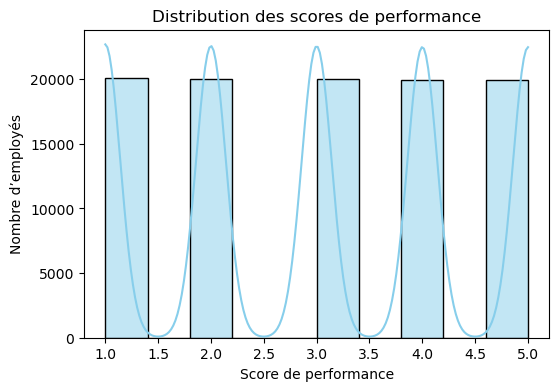

count    100000.000000
mean          2.995430
std           1.414726
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Performance_Score, dtype: float64

In [99]:
plt.figure(figsize=(6, 4))
sns.histplot(perf["Performance_Score"], kde=True, bins=10, color="skyblue")
plt.title("Distribution des scores de performance")
plt.xlabel("Score de performance")
plt.ylabel("Nombre d’employés")
plt.show()

perf["Performance_Score"].describe()


- La **moyenne (≈ 3.0)** et la **médiane (3)** montrent une **distribution relativement équilibrée**, centrée sur une performance "moyenne" dans l’entreprise.
- L’**écart-type élevé (1.41)** indique une **dispersion importante** des scores, ce qui confirme l’intérêt de chercher des **écarts explicables entre groupes (départements, postes, etc.)**.
- La distribution est **bornée entre 1 et 5**, ce qui suggère une **échelle d’évaluation standardisée** (type Likert ou grille interne).

### Implication pour la suite :
- Les différences de score ne sont **ni rares, ni négligeables** → il est légitime de tester s’il existe des facteurs RH (département, ancienneté, satisfaction…) **associés à une meilleure ou moins bonne performance**.
- La distribution étant **ni trop asymétrique, ni fortement biaisée**, on peut envisager un **test ANOVA** pour comparer les moyennes entre départements (ou autres groupes catégoriels).


## Performance et variables qualitatives

### Performance et Departement

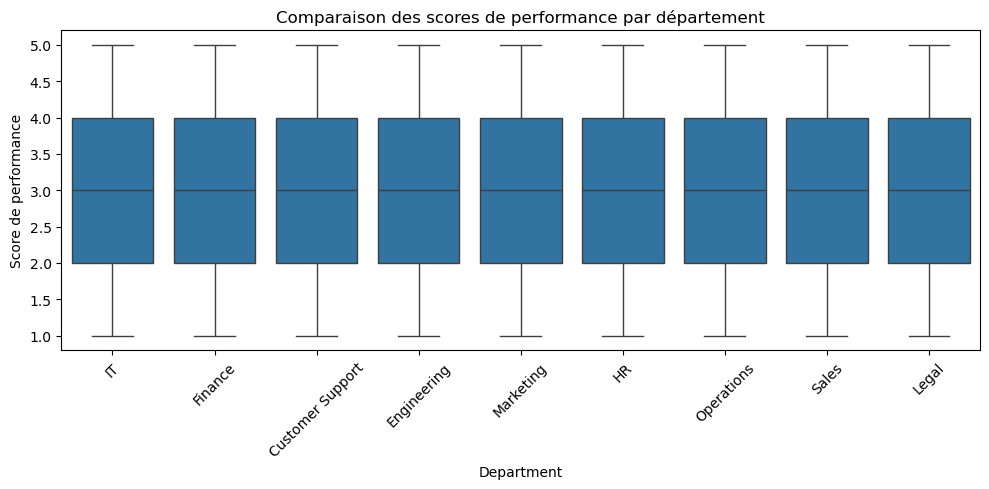

In [100]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Department", y="Performance_Score", data=perf)
plt.title("Comparaison des scores de performance par département")
plt.xticks(rotation=45)
plt.ylabel("Score de performance")
plt.tight_layout()
plt.show()


Visuellement, on observe que tous les départements présentent :

Une médiane autour de 3, ce qui est cohérent avec la moyenne globale (≈2.99); Une dispersion très similaire entre 1 et 5 (valeurs minimum et maximum identiques); Des boîtes de mêmes tailles, ce qui suggère une distribution équivalente des scores à l’intérieur de chaque département : Il n’y a donc aucun département qui se démarque clairement par des performances significativement plus hautes ou plus basses.

Il n’y a pas de différence visible marquée entre les départements en ce qui concerne le score de performance.

Mais une interprétation statistique rigoureuse nécessite une validation par test statistique, car un écart subtil peut exister sans être visuellement évident sur un boxplot. Ainsi, nous allons passé au test statistique.

In [101]:
# Préparer les groupes
grouped_perf = [group["Performance_Score"].values for _, group in perf.groupby("Department")]

# Test de Kruskal-Wallis
stat, p = kruskal(*grouped_perf)
print(f"Kruskal-Wallis H-statistic : {stat:.3f} | p-value : {p:.4f}")


Kruskal-Wallis H-statistic : 7.658 | p-value : 0.4676


#### Aucune différence de performance significative entre départements

Le test de Kruskal-Wallis, appliqué aux scores de performance selon les départements, montre que les variations observées ne sont pas significatives (p = 0.4676).  

Cela signifie que la performance des employés **ne dépend pas structurellement du département auquel ils appartiennent**.

Il est donc nécessaire d’explorer d’autres facteurs RH (ancienneté, satisfaction, type de poste, etc.) pour comprendre les écarts de performance entre individus.


### Performance et Niveau d'étude/Poste/Genre

C:\Users\User\AppData\Local\Temp\ipykernel_6364\2221258734.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Education_Level", y="Performance_Score", data=perf, palette="Set1")


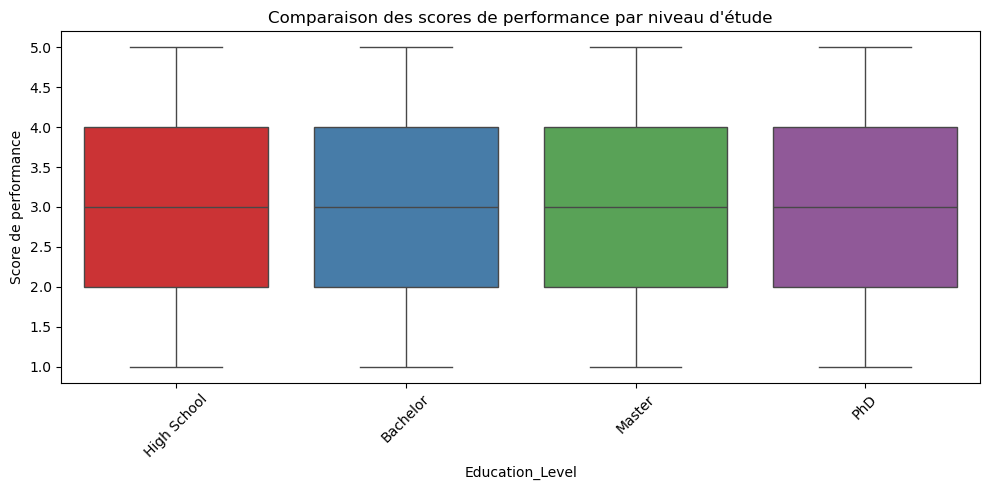

In [102]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Education_Level", y="Performance_Score", data=perf, palette="Set1")
plt.title("Comparaison des scores de performance par niveau d'étude")
plt.xticks(rotation=45)
plt.ylabel("Score de performance")
plt.tight_layout()
plt.show()

In [103]:
# Préparer les groupes
genre_perf = [group["Performance_Score"].values for _, group in perf.groupby("Gender")]
poste_perf = [group["Performance_Score"].values for _, group in perf.groupby("Job_Title")]
edu_perf = [group["Performance_Score"].values for _, group in perf.groupby("Education_Level")]


# Test de Kruskal-Wallis
stat, p = kruskal(*edu_perf)
print(f"Kruskal-Wallis H-statistic pour le niveau d'etude : {stat:.3f} | p-value : {p:.4f}")

stat, p = kruskal(*genre_perf)
print(f"Kruskal-Wallis H-statistic pour le genre : {stat:.3f} | p-value : {p:.4f}")

stat, p = kruskal(*poste_perf)
print(f"Kruskal-Wallis H-statistic pour le poste : {stat:.3f} | p-value : {p:.4f}")

Kruskal-Wallis H-statistic pour le niveau d'etude : 7.026 | p-value : 0.0711
Kruskal-Wallis H-statistic pour le genre : 1.167 | p-value : 0.5578
Kruskal-Wallis H-statistic pour le poste : 5.043 | p-value : 0.5384



L’objectif était d’analyser si certaines caractéristiques qualitatives des employés pouvaient expliquer des écarts de performance observés dans l’entreprise. Pour cela, le test statistique non paramétrique (Kruskal-Wallis) a été appliqué.


- Aucun de ces facteurs qualitatifs ne semble **statistiquement influencer le score de performance**.
- Les performances sont **homogènes** entre les différents départements, niveaux d’études, genres et types de poste.
- Cela suggère que la performance est probablement **plus liée à des facteurs individuels ou comportementaux** qu’à la structure organisationnelle.


 Les leviers classiques comme le département, le diplôme ou le genre **ne suffisent pas à expliquer les différences de performance**. Il est donc pertinent d'explorer des **variables quantitatives**.

Cela permettra de mieux cerner **les profils performants** et d'orienter les **décisions RH** sur des éléments concrets et actionnables.


## Performance et variables quantitatives
Nous allons étudier la relation entre la performance et la satisfaction, l'âge, le salaire mensuel, les heures travaillées par semaine des employés.


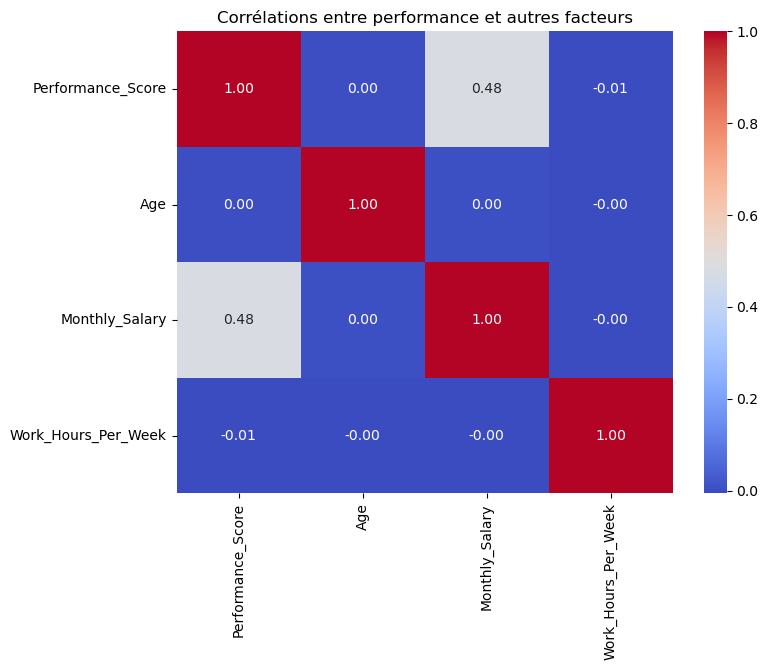

In [104]:
# Sélection des variables d'intérêt
vars_corr = ['Performance_Score', 'Age', 'Monthly_Salary', 'Work_Hours_Per_Week']

# Calcul de la matrice de corrélation
corr_matrix = perf[vars_corr].corr(method='spearman')

# Affichage de la matrice avec seaborn
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélations entre performance et autres facteurs")
plt.show()


D'après ce heatmap, **le seul facteur réellement corrélé à la performance est le salaire mensuel**.
    - Cela peut refléter une politique salariale **liée à la performance** (bonus, primes, ancienneté méritée…)
    - Ou inversement, les employés mieux payés **produisent effectivement de meilleures performances**.

**Aucune autre variable quantitative analysée n’explique les variations de performance** : ni l’âge, ni les heures travaillées, ni même le score de satisfaction.

Cela suggère que la **performance est peu liée aux facteurs personnels standards** (âge, volume horaire, satisfaction) et davantage à des critères internes de reconnaissance ou de poste (ex. : responsabilités).

Cette conclusion ouvre la voie à une **analyse approfondie du salaire, des promotions ou des responsabilités** comme facteurs explicatifs.


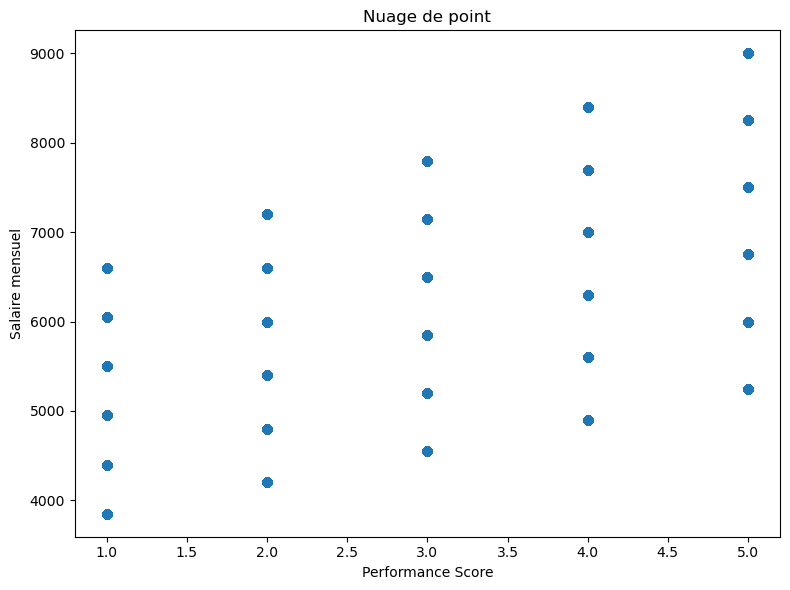

In [105]:
# Representation graphique de la performance et le salaire mensuel
plt.figure(figsize=(8,6))
plt.scatter(perf['Performance_Score'], perf['Monthly_Salary'])
plt.title('Nuage de point')
plt.xlabel('Performance Score')
plt.ylabel('Salaire mensuel')
plt.tight_layout()
plt.show()


L’analyse met en évidence que **le seul facteur quantitatif ayant un lien mesurable avec la performance est le salaire**.  
Les autres variables comme l’âge, les heures travaillées ou la satisfaction déclarée **n’ont pas montré d’influence statistique notable** sur les résultats de performance.

Cela peut traduire une **politique salariale fondée sur la reconnaissance de la performance**, ou une **association structurelle entre ancienneté, poste à responsabilité et score de performance**.


## Profil des hauts performeurs
Identifier les caractéristiques des employés les plus performants (ceux ayant un Performance_Score de 4 ou 5) afin de dresser un profil type. Cela peut orienter les décisions RH : recrutement, promotion, formation, rétention.

In [106]:
# Création d’un segment “haut performeurs”
# Création d'une colonne booléenne
perf['Top_Performer'] = perf['Performance_Score'] >= 4

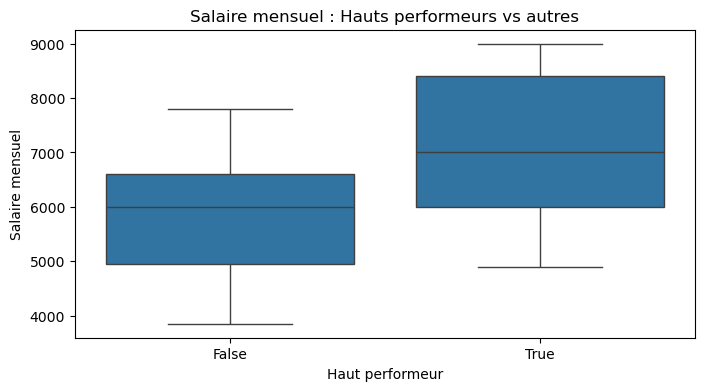

In [107]:
# Comparaison des salaires
plt.figure(figsize=(8,4))
sns.boxplot(data=perf, x='Top_Performer', y='Monthly_Salary')
plt.title('Salaire mensuel : Hauts performeurs vs autres')
plt.xlabel('Haut performeur')
plt.ylabel('Salaire mensuel')
plt.savefig("Boxplot.png")
plt.show()


In [108]:
from scipy.stats import mannwhitneyu

# Exemple sur le salaire
group_top = perf[perf['Top_Performer'] == True]['Monthly_Salary']
group_rest = perf[perf['Top_Performer'] == False]['Monthly_Salary']

stat, p = mannwhitneyu(group_top, group_rest)
print(f"Mann-Whitney U pour le salaire : U={stat:.2f} | p-value={p:.4f}")


Mann-Whitney U pour le salaire : U=1784718706.50 | p-value=0.0000


D'après ce visuel et le test de Mann-Whitney U, nous pouvons confirmer une différence significative entre les salaires des hauts performeurs et des autres (p-value = 0.0000).
Cela suggère que la politique salariale valorise réellement la performance. 
La performance des employés dans cette entreprise est fortement corrélée au salaire, mais pas aux autres variables mesurées : soit les employés performants sont récompensés par un meilleur salaire ou soit les postes mieux rémunérés attirent ou favorisent des profils naturellement plus performants.

# CONCLUSION GENERALE

Cette analyse exploratoire et statistique a permis d’examiner en profondeur les écarts de performance au sein d’une entreprise en croisant des données qualitatives (département, genre, éducation, poste) et quantitatives (salaire, heures, satisfaction, ancienneté).

**Résultats principaux** 
- Profil des employés stable et équilibré : répartition homogène des genres, des postes et des départements, créant une base statistique robuste.

- Pas d’influence significative des variables qualitatives (département, genre, niveau d’étude, poste) sur les performances : les écarts observés ne sont pas dus à la structure organisationnelle.

- Le salaire est la seule variable quantitative corrélée à la performance, ce qui suggère une politique RH fondée sur la reconnaissance des résultats.

Aucune corrélation significative avec les heures travaillées, l’âge ou la satisfaction, ce qui remet en question certaines hypothèses classiques sur la productivité.

 **Recommandations métiers**
 
- Renforcer l’analyse de la rémunération pour s'assurer qu'elle reflète bien les performances et évite les biais (ex. ancienneté vs mérite).

- Explorer les trajectoires de carrière pour comprendre comment ancienneté et promotions influencent la performance.

- Cibler les jeunes recrues et profils techniques avec des politiques de rétention adaptées.

- Éviter de tirer des conclusions trop rapides basées sur la structure (département, poste).

- Se concentrer sur des indicateurs comportementaux et individuels (initiative, qualité du travail, collaboration).

- Compléter les données avec des indicateurs de performance qualitative (évaluations managériales, feedbacks d’équipe).